In [1]:
# Shared visualization style — used across all figures in this chapter
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Rectangle
import numpy as np

FIGSIZE        = (10, 4.5)
TITLE_FS       = 22
LABEL_FS       = 18
TICK_FS        = 15
BAR_HEIGHT     = 0.85
CONTENT_COLOR  = "#87ceeb"
PADDING_COLOR  = "#d3d3d3"
ACCENT_COLOR   = "#E05A5A"

SEGMENT_COLORS = [
    "#a6cee3",  # light blue
    "#b2df8a",  # light green
    "#fb9a99",  # soft red
    "#fdbf6f",  # light orange
    "#cab2d6",  # lavender
    "#ffe066",  # warm yellow
    "#a8d8ea",  # powder blue
    "#90ee90",  # light green 2
    "#fbb4ae",  # rose pink
    "#b3cde3",  # powder blue 2
    "#ccebc5",  # mint
    "#decbe4",  # lilac
    "#fed9a6",  # peach
    "#c7e9b4",  # pale sage
]

LEGEND_KW = dict(
    loc="upper center", bbox_to_anchor=(0.5, -0.18),
    ncol=3, fontsize=TICK_FS, framealpha=0.8, edgecolor="#cccccc"
)

class RainbowPatchHandler(HandlerBase):
    """Draws a legend key as a row of colored segments."""
    def __init__(self, colors):
        self.colors = colors
        super().__init__()

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        n = len(self.colors)
        seg_w = width / n
        return [
            Rectangle([xdescent + i * seg_w, ydescent], seg_w, height,
                      facecolor=c, edgecolor="none", transform=trans)
            for i, c in enumerate(self.colors)
        ]

def _style_bar_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    ax.tick_params(colors="#888888")
    ax.xaxis.label.set_color("#444444")
    ax.yaxis.label.set_color("#444444")
    ax.title.set_color("#222222")

def _style_packing_ax(ax):
    for spine in ax.spines.values():
        spine.set_color("#cccccc")
        spine.set_linewidth(1)
    ax.tick_params(colors="#888888")
    ax.xaxis.label.set_color("#444444")
    ax.yaxis.label.set_color("#444444")
    ax.title.set_color("#222222")

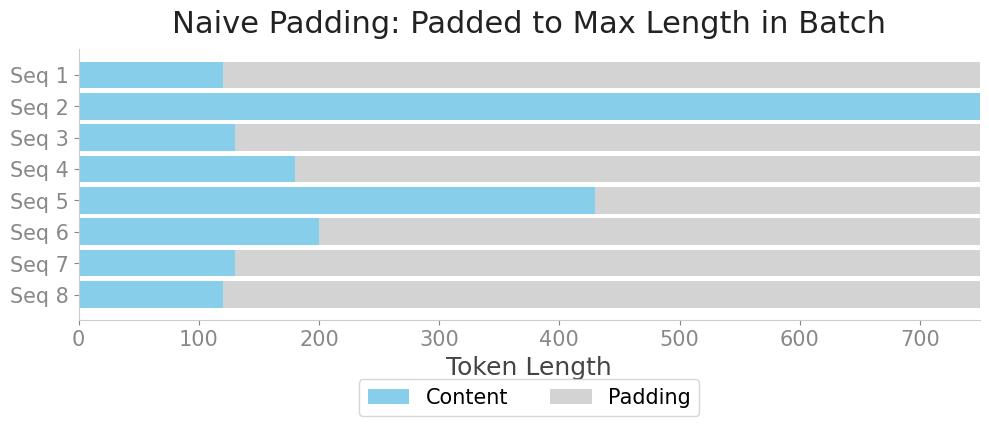

In [2]:
content_lengths = [120, 750, 130, 180, 430, 200, 130, 120]
max_len = max(content_lengths)
labels = [f"Seq {i+1}" for i in range(len(content_lengths))]

fig, ax = plt.subplots(figsize=FIGSIZE)
y = np.arange(len(content_lengths))

ax.barh(y, content_lengths, color=CONTENT_COLOR, label="Content", height=BAR_HEIGHT)
ax.barh(y, [max_len - c for c in content_lengths], left=content_lengths,
        color=PADDING_COLOR, label="Padding", height=BAR_HEIGHT)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=TICK_FS)
ax.set_xlabel("Token Length", fontsize=LABEL_FS)
ax.set_title("Naive Padding: Padded to Max Length in Batch", fontsize=TITLE_FS, pad=12)
ax.tick_params(axis="x", labelsize=TICK_FS)
ax.legend(fontsize=TICK_FS, loc="upper center", bbox_to_anchor=(0.5, -0.18),
          ncol=2, framealpha=0.8, edgecolor="#cccccc")
ax.invert_yaxis()
_style_bar_ax(ax)

plt.tight_layout()
plt.savefig("naive_padding.png", dpi=300, bbox_inches="tight")
plt.show()

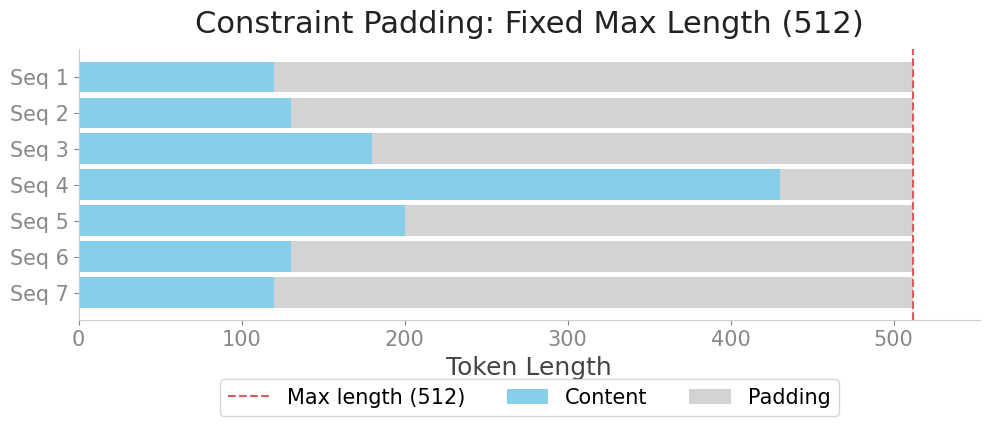

In [3]:
content_lengths = [120, 130, 180, 430, 200, 130, 120]
max_len = 512
labels = [f"Seq {i+1}" for i in range(len(content_lengths))]

fig, ax = plt.subplots(figsize=FIGSIZE)
y = np.arange(len(content_lengths))

ax.barh(y, content_lengths, color=CONTENT_COLOR, label="Content", height=BAR_HEIGHT)
padding = [max(0, max_len - c) for c in content_lengths]
ax.barh(y, padding, left=[min(c, max_len) for c in content_lengths],
        color=PADDING_COLOR, label="Padding", height=BAR_HEIGHT)
ax.axvline(x=max_len, color=ACCENT_COLOR, linestyle="--", linewidth=1.5,
           label=f"Max length ({max_len})")

# Extend x-axis so the red line is clearly inside the plot
ax.set_xlim(0, max_len * 1.08)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=TICK_FS)
ax.set_xlabel("Token Length", fontsize=LABEL_FS)
ax.set_title(f"Constraint Padding: Fixed Max Length ({max_len})", fontsize=TITLE_FS, pad=12)
ax.tick_params(axis="x", labelsize=TICK_FS)
ax.legend(fontsize=TICK_FS, loc="upper center", bbox_to_anchor=(0.5, -0.18),
          ncol=3, framealpha=0.8, edgecolor="#cccccc")
ax.invert_yaxis()
_style_bar_ax(ax)

plt.tight_layout()
plt.savefig("constraint_padding.png", dpi=300, bbox_inches="tight")
plt.show()

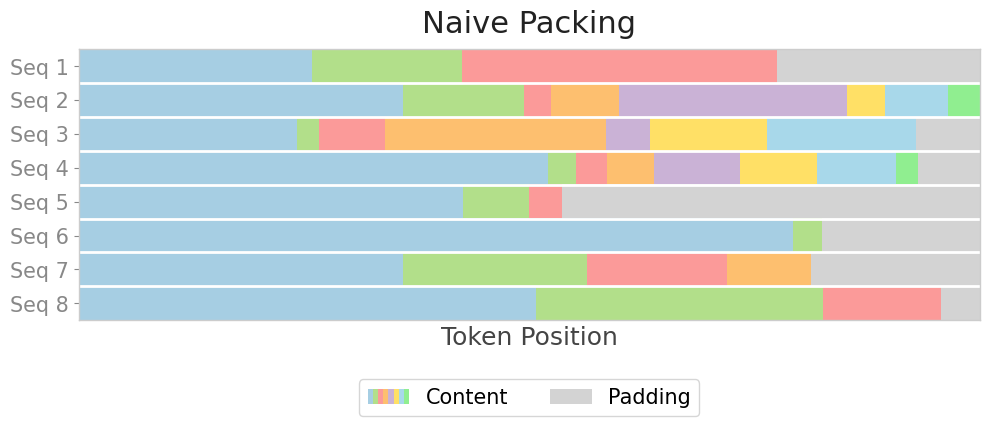

In [4]:
max_length = 2048
batch = [
    [528, 342, 715],
    [736, 274, 62, 155, 516, 86, 145, 73],
    [495, 51, 148, 503, 99, 267, 337],
    [1065, 63, 71, 106, 195, 175, 181, 48],
    [872, 150, 75],
    [1622, 66],
    [736, 418, 317, 192],
    [1038, 652, 268],
]

vis = np.zeros((len(batch), max_length), dtype=int)
for i, sample in enumerate(batch):
    pos = 0
    for j, seg_len in enumerate(sample):
        vis[i, pos:pos + seg_len] = j + 1
        pos += seg_len

colors = [PADDING_COLOR] + SEGMENT_COLORS
n_unique = len(np.unique(vis))
cmap = mcolors.ListedColormap(colors[:n_unique])

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.imshow(vis, aspect="auto", cmap=cmap, interpolation="nearest", vmin=0, vmax=n_unique - 1)

ax.set_yticks(np.arange(len(batch)))
ax.set_yticklabels([f"Seq {i+1}" for i in range(len(batch))], fontsize=TICK_FS)
ax.set_xticks([])
ax.set_xlabel("Token Position", fontsize=LABEL_FS)
ax.set_title("Naive Packing", fontsize=TITLE_FS, pad=12)
_style_packing_ax(ax)

for y_pos in np.arange(0.5, len(batch) - 0.5):
    ax.axhline(y_pos, color="white", linewidth=2)

rainbow_patch = mpatches.Patch(label="Content")
padding_patch = mpatches.Patch(facecolor=PADDING_COLOR, label="Padding")
ax.legend(
    handles=[rainbow_patch, padding_patch],
    handler_map={rainbow_patch: RainbowPatchHandler(SEGMENT_COLORS[:8])},
    **LEGEND_KW
)

plt.tight_layout()
plt.savefig("naive_packing.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
from datasets import load_dataset
from transformers import AutoTokenizer

dataset = load_dataset("HuggingFaceM4/FineVisionMax", split="train", streaming=True)
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")

def tokenize_sample(sample):
    messages_list = []
    for data_dict in sample['texts']:
        messages_list.append({'role': 'user', 'content': data_dict['user']})
        messages_list.append({'role': 'assistant', 'content': data_dict['assistant']})
    tokens = tokenizer.apply_chat_template(messages_list, tokenize=True)
    return tokens['input_ids']

pool_tokens = []
pool_size = 50
for sample in dataset:
    toks = tokenize_sample(sample)
    if len(toks) <= max_length:
        pool_tokens.append(toks)
        if len(pool_tokens) >= pool_size:
            break

pool_tokens.sort(key=len, reverse=True) # Sort by length descending

batch_tokens = []
for toks in pool_tokens:
    placed = False
    # Try to place in an existing row
    for row_idx, row in enumerate(batch_tokens):
        curr_len = sum(len(seg) for seg in row)
        if curr_len + len(toks) <= max_length:
            batch_tokens[row_idx].append(toks)
            placed = True
            break
    if placed:
        continue
    # Could not place in any existing row, start a new row if possible
    batch_tokens.append([toks])

Resolving data files:   0%|          | 0/10000 [00:00<?, ?it/s]

In [14]:
from typing import List

def to_vis_matrix(batch_lengths: List[List[int]], max_length: int):
    import numpy as np
    vis = np.zeros((len(batch_lengths), max_length), dtype=int)
    for i, row in enumerate(batch_lengths):
        pos = 0
        for j, seg_len in enumerate(row):
            vis[i, pos:pos+seg_len] = j + 1
            pos += seg_len
    return vis

batch_lengths = [[len(x) for x in y] for y in batch_tokens]


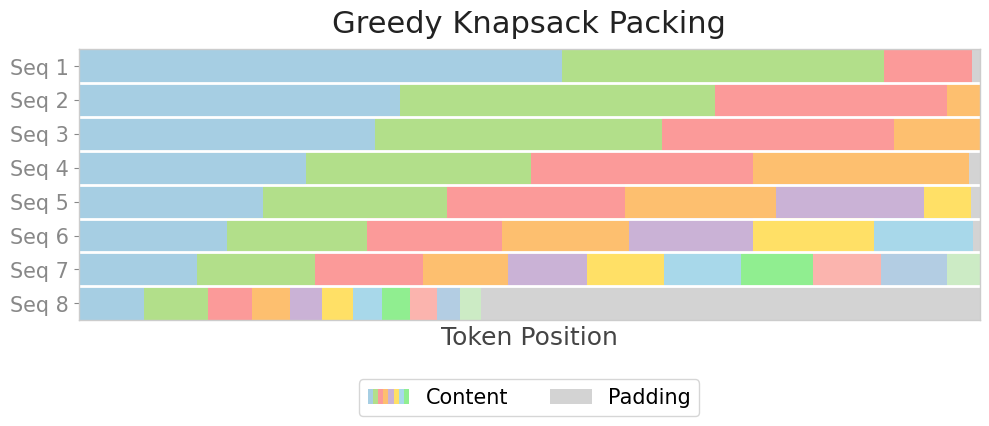

In [16]:
def plot_knapsack(batch_lengths, max_length, title):
    
    vis = to_vis_matrix(batch_lengths, max_length)
    
    n_unique = len(np.unique(vis))
    cmap = mcolors.ListedColormap(colors[:n_unique])
    
    n_rows = len(batch_lengths)
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.imshow(vis, aspect="auto", cmap=cmap, interpolation="nearest", vmin=0, vmax=n_unique - 1)
    
    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels([f"Seq {i+1}" for i in range(n_rows)], fontsize=TICK_FS)
    ax.set_xticks([])
    ax.set_xlabel("Token Position", fontsize=LABEL_FS)
    ax.set_title(title, fontsize=TITLE_FS, pad=12)
    _style_packing_ax(ax)
    
    for y_pos in np.arange(0.5, n_rows - 0.5):
        ax.axhline(y_pos, color="white", linewidth=2)
    
    rainbow_patch = mpatches.Patch(label="Content")
    padding_patch = mpatches.Patch(facecolor=PADDING_COLOR, label="Padding")
    ax.legend(
        handles=[rainbow_patch, padding_patch],
        handler_map={rainbow_patch: RainbowPatchHandler(SEGMENT_COLORS[:8])},
        **LEGEND_KW
    )
    
    plt.tight_layout()
    plt.savefig(f"{title.lower().replace(" ", "_")}.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_knapsack(batch_lengths, max_length, "Greedy Knapsack Packing") 

In [17]:
def balanced_greedy_knapsack(samples, L):
   # Step 1: Sort the samples
   samples.sort(key=len, reverse=True)
   total_length = sum([len(sample) for sample in samples])
   min_knapsacks = (total_length + L - 1) // L
   # Step 2: Initialize knapsacks
   knapsacks=[[] for _ in range(min_knapsacks)]
   knapsack_lengths = [0] * min_knapsacks
   # Step 3: Distribute samples across knapsacks
   ks_index = 0
   sample_index = 0
   while sample_index < len(samples):
       length = len(samples[sample_index])
       if knapsack_lengths[ks_index]+length<=L:
           knapsacks[ks_index].append(length)
           knapsack_lengths[ks_index] += length
           sample_index += 1
       else:
           knapsacks.append([])
           knapsack_lengths.append(0)
       ks_index = np.argmin(knapsack_lengths)
   return knapsacks

In [18]:
knapsacks = balanced_greedy_knapsack(pool_tokens, 2048)

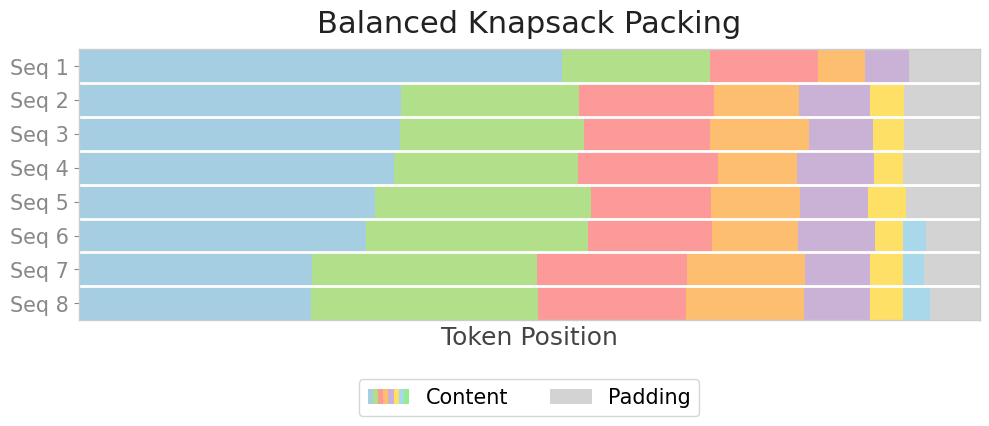

In [19]:
plot_knapsack(knapsacks, max_length, "Balanced Knapsack Packing")